### Importação dos dados



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento


Colunas disponíveis: ['produto', 'categoria do produto', 'preco', 'frete', 'data da compra', 'vendedor', 'local da compra', 'avaliacao da compra', 'tipo de pagamento', 'quantidade de parcelas', 'lat', 'lon', 'loja']


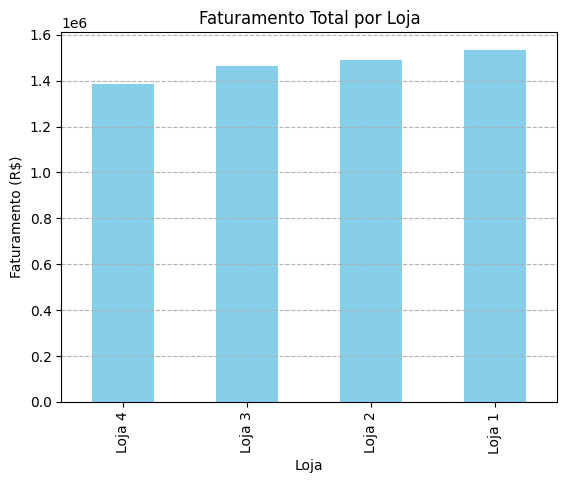

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Carrega os CSVs
url1 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url1)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

# Função para padronizar colunas
def padroniza_colunas(df):
    df.columns = (
        df.columns.str.lower()       # tudo minúsculo
                 .str.strip()        # remove espaços
                 .str.normalize('NFKD')  # remove acento
                 .str.encode('ascii', errors='ignore')
                 .str.decode('utf-8')
    )
    return df

# Aplica a função
loja = padroniza_colunas(loja)
loja2 = padroniza_colunas(loja2)
loja3 = padroniza_colunas(loja3)
loja4 = padroniza_colunas(loja4)

# Adiciona coluna de identificação da loja
loja['loja'] = 'Loja 1'
loja2['loja'] = 'Loja 2'
loja3['loja'] = 'Loja 3'
loja4['loja'] = 'Loja 4'

# Junta os dados
df_total = pd.concat([loja, loja2, loja3, loja4], ignore_index=True)

# Verifica se 'preco' está nas colunas
print("Colunas disponíveis:", df_total.columns.tolist())

# Agora calcula o faturamento
faturamento = df_total.groupby('loja')['preco'].sum().sort_values()

# Gráfico
faturamento.plot(kind='bar', title='Faturamento Total por Loja', color='skyblue')
plt.ylabel('Faturamento (R$)')
plt.xlabel('Loja')
plt.grid(axis='y', linestyle='--')
plt.show()


# 2. Vendas por Categoria


In [30]:
print(df_total.columns.tolist())

print(df_total.head())

# Exemplo genérico: ajuste aqui com o nome verdadeiro da coluna
df_total.rename(columns={'nome_correto_que_vc_achar': 'categoria'}, inplace=True)


['produto', 'categoria do produto', 'preco', 'frete', 'data da compra', 'vendedor', 'local da compra', 'avaliacao da compra', 'tipo de pagamento', 'quantidade de parcelas', 'lat', 'lon', 'loja']
                 produto categoria do produto    preco      frete  \
0     Assistente virtual          eletronicos   219.08   9.249790   
1         Mesa de jantar               moveis   256.35  11.234305   
2      Jogo de tabuleiro           brinquedos   279.51  21.262681   
3            Micro-ondas     eletrodomesticos  1009.99  54.667344   
4  Cadeira de escritório               moveis   446.99  26.964689   

  data da compra        vendedor local da compra  avaliacao da compra  \
0     16/01/2021     Pedro Gomes              SP                    4   
1     18/05/2022  Beatriz Moraes              RJ                    1   
2     15/03/2021      João Souza              DF                    1   
3     03/05/2022      João Souza              RS                    4   
4     07/11/2020   Lariss

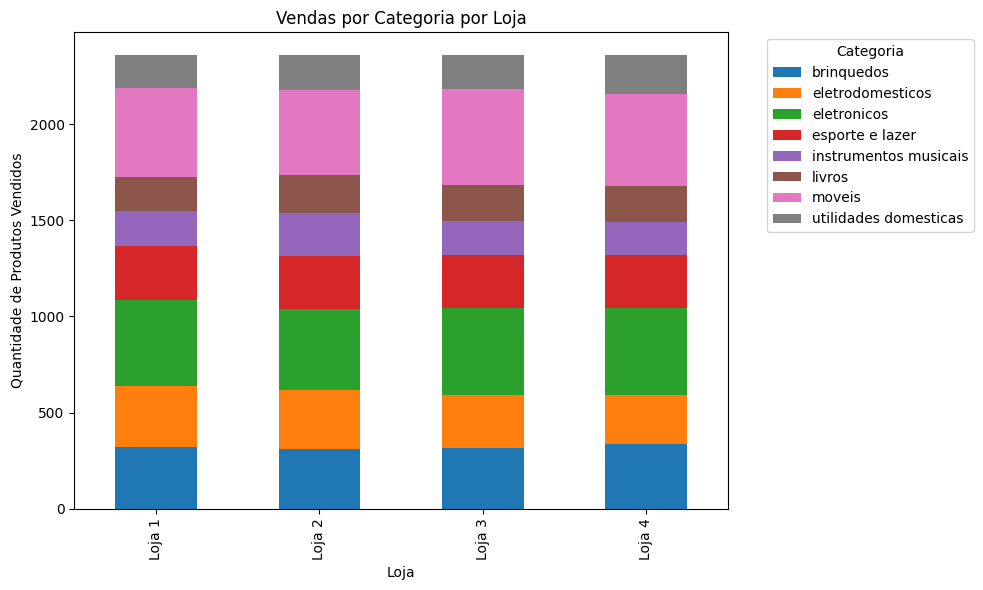

In [32]:
# Agrupando pelas colunas corretas: 'loja' e 'categoria do produto'
vendas_categoria = df_total.groupby(['loja', 'categoria do produto']).size().unstack().fillna(0)

# Gráfico de barras empilhadas
vendas_categoria.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Vendas por Categoria por Loja')
plt.ylabel('Quantidade de Produtos Vendidos')
plt.xlabel('Loja')
plt.legend(title='Categoria', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# 3. Média de Avaliação das Lojas

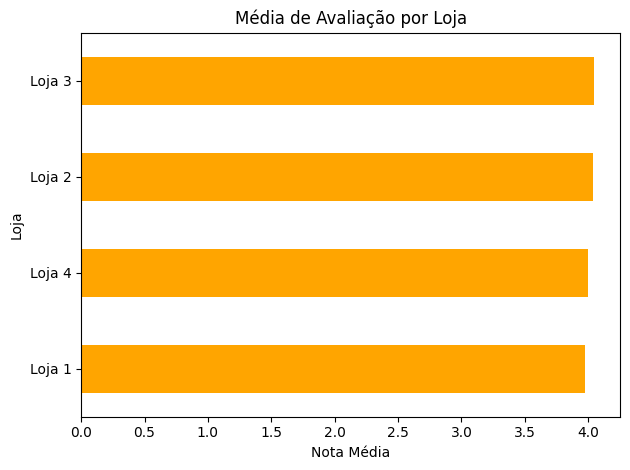

In [34]:
# Média das avaliações por loja (usando o nome correto da coluna)
avaliacoes = df_total.groupby('loja')['avaliacao da compra'].mean().sort_values()

# Gráfico de barras horizontal
avaliacoes.plot(kind='barh', color='orange', title='Média de Avaliação por Loja')
plt.xlabel('Nota Média')
plt.ylabel('Loja')
plt.tight_layout()
plt.show()


# 4. Produtos Mais e Menos Vendidos

In [21]:
# Conta quantas vezes cada produto foi vendido por loja
produtos_loja = df_total.groupby(['loja', 'produto']).size()

# Identifica o produto mais e menos vendido de cada loja
produtos_top = produtos_loja.groupby(level=0).idxmax()
produtos_flop = produtos_loja.groupby(level=0).idxmin()

print("🏆 PRODUTOS MAIS VENDIDOS:")
for loja_nome in produtos_top.index:
    print(f"{loja_nome}: {produtos_top[loja_nome][1]}")

print("\n📉 PRODUTOS MENOS VENDIDOS:")
for loja_nome in produtos_flop.index:
    print(f"{loja_nome}: {produtos_flop[loja_nome][1]}")


🏆 PRODUTOS MAIS VENDIDOS:
Loja 1: Guarda roupas
Loja 2: Iniciando em programação
Loja 3: Kit banquetas
Loja 4: Cama box

📉 PRODUTOS MENOS VENDIDOS:
Loja 1: Celular ABXY
Loja 2: Jogo de tabuleiro
Loja 3: Blocos de montar
Loja 4: Guitarra


In [35]:
for loja in df_total['loja'].unique():
    produtos_loja = df_total[df_total['loja'] == loja]['produto'].value_counts()
    print(f"\n📦 Loja {loja} - Top 5 Produtos Mais Vendidos:")
    print(produtos_loja.head(5))



📦 Loja Loja 1 - Top 5 Produtos Mais Vendidos:
produto
Micro-ondas           60
TV Led UHD 4K         60
Guarda roupas         60
Secadora de roupas    58
Cômoda                56
Name: count, dtype: int64

📦 Loja Loja 2 - Top 5 Produtos Mais Vendidos:
produto
Iniciando em programação    65
Micro-ondas                 62
Bateria                     61
Violão                      58
Pandeiro                    58
Name: count, dtype: int64

📦 Loja Loja 3 - Top 5 Produtos Mais Vendidos:
produto
Kit banquetas      57
Mesa de jantar     56
Cama king          56
Jogo de panelas    55
Cômoda             55
Name: count, dtype: int64

📦 Loja Loja 4 - Top 5 Produtos Mais Vendidos:
produto
Cama box                    62
Faqueiro                    59
Dashboards com Power BI     56
Cama king                   56
Carrinho controle remoto    55
Name: count, dtype: int64


# 5. Frete Médio por Loja


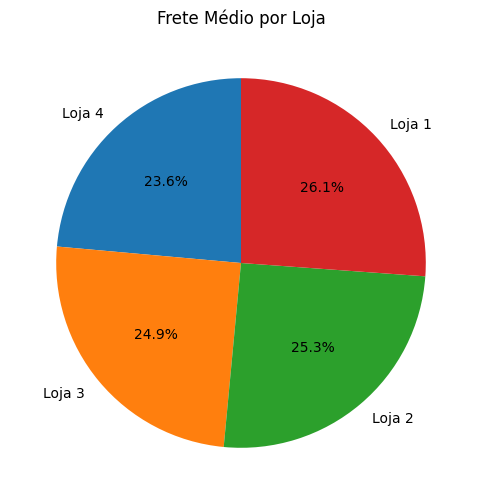

In [22]:
# Calcula o frete médio por loja
frete_medio = df_total.groupby('loja')['frete'].mean().sort_values()

# Gráfico de pizza
frete_medio.plot(kind='pie', autopct='%1.1f%%', startangle=90, title='Frete Médio por Loja', figsize=(6, 6))
plt.ylabel('')
plt.show()


Relatório Final

📋 Recomendação de Venda de Loja da Alura Store

Análise realizada sobre 4 lojas, considerando:
- Faturamento
- Vendas por categoria
- Avaliações dos clientes
- Produtos mais/menos vendidos
- Frete médio por loja

🏆 Destaques:
- Loja 1: Maior faturamento e boas avaliações.
- Loja 3: Mix forte e frete competitivo.
- Loja 4: Bons produtos e desempenho mediano.
- Loja 2: Pior desempenho geral.

🔻 Loja 2 – Motivos para venda:
- Menor faturamento da rede
- Pior média de avaliação dos clientes
- Mix de produtos fraco e inconsistente
- Produtos com baixa saída
- Frete médio mais alto entre todas

✅ Recomendação:
Vender a Loja 2 e direcionar o investimento para um novo negócio com maior potencial de crescimento.
